In [1430]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Przygotowanie danych

### Pobranie danych z pliku

dict_keys(['__header__', '__version__', '__globals__', 'H'])


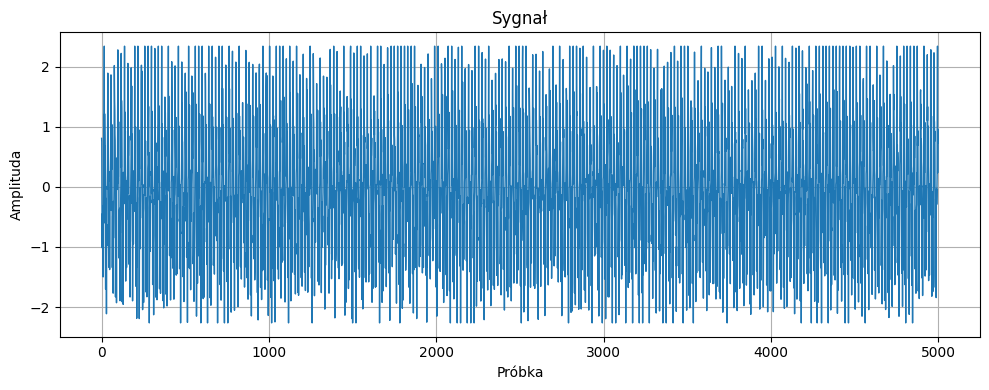

In [1431]:
from scipy.io import loadmat

# wczytanie pliku
data = loadmat('assets/vibration_dataset/Faulty/F60.mat')
# data = loadmat('assets/vibration_dataset/Healthy/H1.mat')
print(data.keys())
signal = data["H"][:,1]
plt.figure(figsize=(10, 4))
plt.plot(signal, linewidth=1)
plt.title(f"Sygnał")
plt.xlabel("Próbka")
plt.ylabel("Amplituda")
plt.grid(True)
plt.tight_layout()
plt.show()

### Wygenerowanie danych

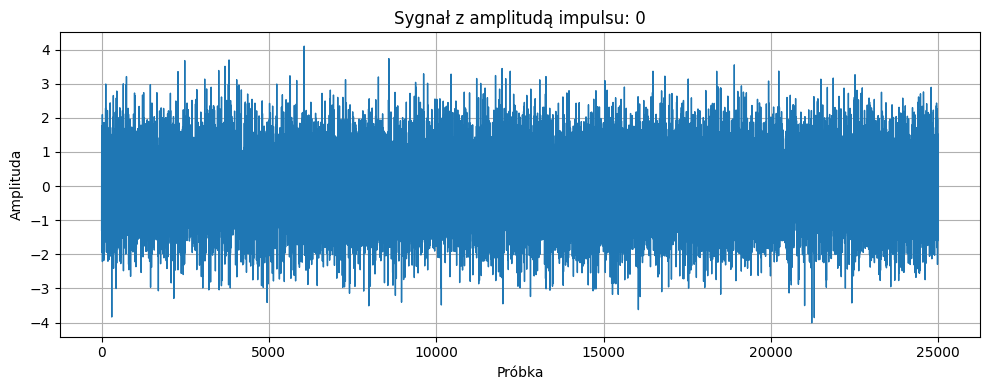

In [1545]:
import impuls_simulator as impuls_simulator
B=0
fs=25000
varsize=25000
fmod=30
f_center=2000
bandwidth=500
shift=0
sigma = 3
signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)
plt.figure(figsize=(10, 4))
plt.plot(signal, linewidth=1)
plt.title(f"Sygnał z amplitudą impulsu: {B}")
plt.xlabel("Próbka")
plt.ylabel("Amplituda")
plt.grid(True)
plt.tight_layout()
plt.show()

## Spektrogram

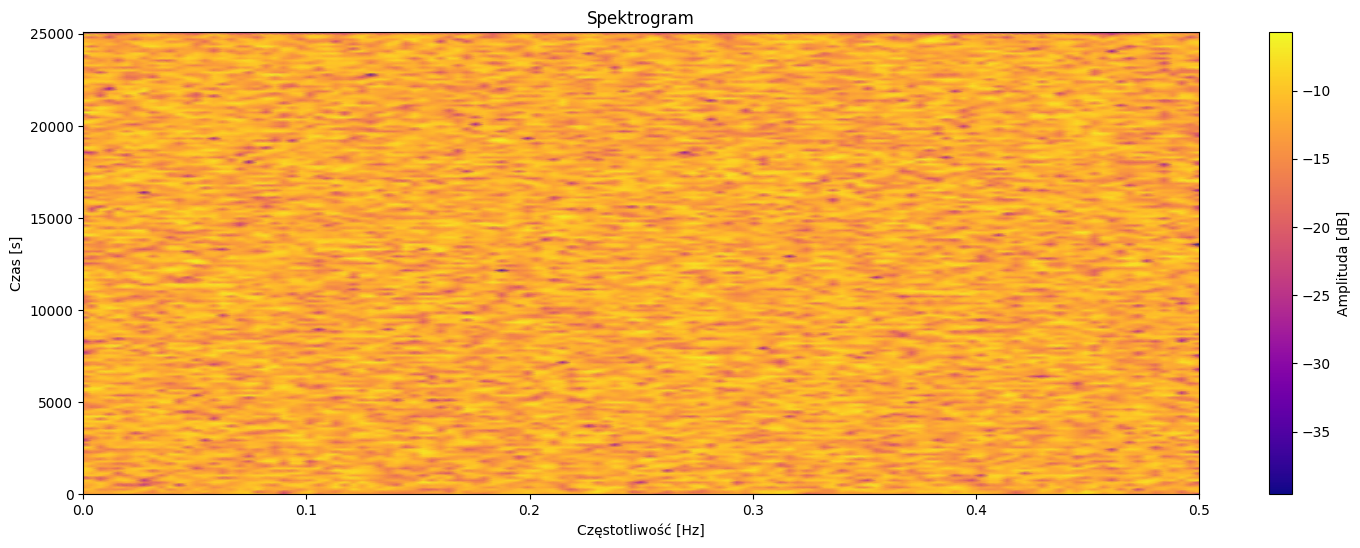

In [1546]:
#obliczenie STFT
fs = 1
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
#Wyrysowanie Wykresu
plt.figure(figsize=(18, 6))
plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Czas [s]')
plt.title('Spektrogram')
plt.colorbar(label='Amplituda [dB]')
plt.show()

# Funkcje do analizy

In [1547]:
#znajdywanie przedziałów wzrostu
# def spike_detection(data, threshold_factor):
#     data = np.array(data)
#     mean_data = np.mean(data)
#     data -= mean_data
#     threshold = mean_data * threshold_factor
#     above = data > threshold

#     # znajdź przejdział
#     ifb = (0,0)
#     start = None

#     for i, v in enumerate(above):
#         if v:
#             if start is None:
#                 start = i
#         else:
#             if start is not None:
#                 if i-start > ifb[1]-ifb[0]:
#                     ifb = (start, i-1)
#                 start = None
#     if start is not None:
#         if len(data) - start > ifb[1] - ifb[0]:
#             ifb = (start, len(data)-1)
#     return ifb

def spike_interval_by_peak(data, threshold_factor=2):
    data = np.array(data)
    baseline = np.median(data)
    uplift = np.std(data)
    threshold = baseline + threshold_factor*uplift

    # 1. Znajdź największy peak powyżej thresholdu
    idx_peak = np.argmax(data)
    if data[idx_peak] < threshold:
        return None  # brak impulsu

    # 2. Rozszerz w lewo
    left = idx_peak
    while left > 0 and data[left] > threshold:
        left -= 1

    # 3. Rozszerz w prawo
    right = idx_peak
    while right < len(data)-1 and data[right] > threshold:
        right += 1


    return left, right, threshold


In [1548]:
def bandpass_filter(signal, fs, f_low, f_high):
    # Wykonanie FFT
    fft_signal = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    
    # Tworzenie maski dla wybranego pasma
    mask = (abs(freqs) >= f_low) & (abs(freqs) <= f_high)
    
    # Aplikacja maski (wyzerowanie składowych poza wybranym pasmem)
    fft_signal_filtered = fft_signal.copy()
    fft_signal_filtered[~mask] = 0
    
    # Odwrotna transformata Fouriera
    filtered_signal = np.real(np.fft.ifft(fft_signal_filtered))
    
    return filtered_signal, freqs, fft_signal, fft_signal_filtered

In [1549]:
def selector_analysis(results,threshold_factor=2):

    left, right, threshold = spike_interval_by_peak(results,threshold_factor)
    print(f"mean:{np.mean(results)}")
    print(f"std:{np.std(results)}")

    #filtracja na podstawie otrzymanych granic
    filtered, freqs, fft_orig, fft_filtered = bandpass_filter(signal, fs, array_freq[left], array_freq[right])
    sigma = np.std(filtered)
    mu = np.mean(filtered)

    #wyrysowanie wykresów
    fig, axes = plt.subplots(1,2, figsize=(18,5))
    axes[0].plot(array_freq,results)
    axes[0].axvline(x=array_freq[left], color='red', linestyle='-')
    axes[0].axvline(x=array_freq[right], color='red', linestyle='-')
    axes[0].axhline(y=threshold, color='green', linestyle='--')
    axes[0].set_title("Wyniki selektora")
    axes[0].set_xlabel("Częstotliwość")
    axes[0].set_ylabel("Wartość selektora")
    axes[0].grid()


    axes[1].plot(filtered)
    axes[1].axhline(y=mu, color='red', linestyle='--')
    axes[1].axhline(y=mu + threshold_factor*sigma, color='green', linestyle='--')
    axes[1].axhline(y=mu - threshold_factor*sigma, color='green', linestyle='--')
    axes[1].set_title("Przefiltrowany sygnał w czasie")
    axes[1].set_xlabel("Czas")
    axes[1].set_ylabel("Amplituda")
    plt.tight_layout()
    plt.show()

    print(np.sum(filtered**2))

    return filtered

# Selektory

mean:0.17816040501625635
std:0.14346382386600817


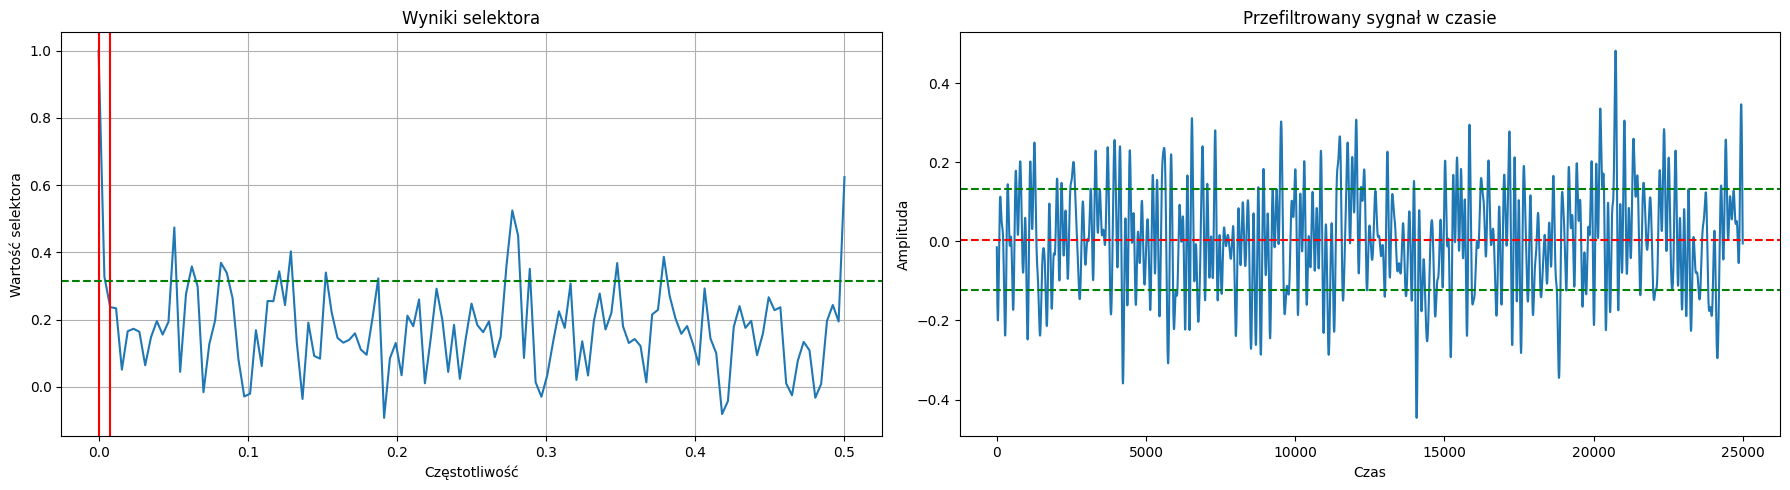

404.39297218346917


In [1550]:
import ifb_selectors as selector
threshold_factor = 1
sk_results = selector.SK(Zxx)
filtered = selector_analysis(sk_results,threshold_factor)

78.25873989437935


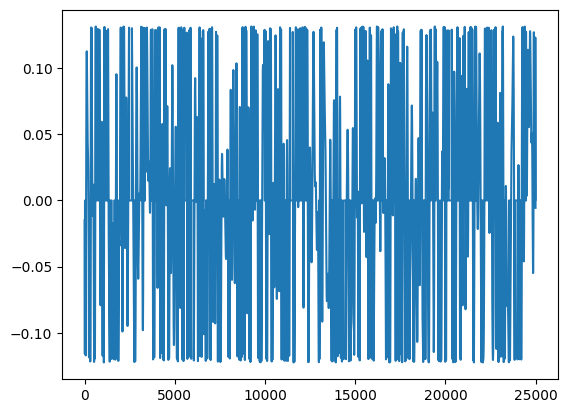

In [1551]:
impulses = (filtered > np.mean(filtered) + threshold_factor*np.std(filtered)) | (filtered < np.mean(filtered) - threshold_factor*np.std(filtered))
filtered_no_impulses = filtered.copy()
filtered_no_impulses[impulses] = 0
plt.plot(filtered_no_impulses)
print(np.sum(filtered_no_impulses**2))

mean:0.17816040501625635
std:0.14346382386600817


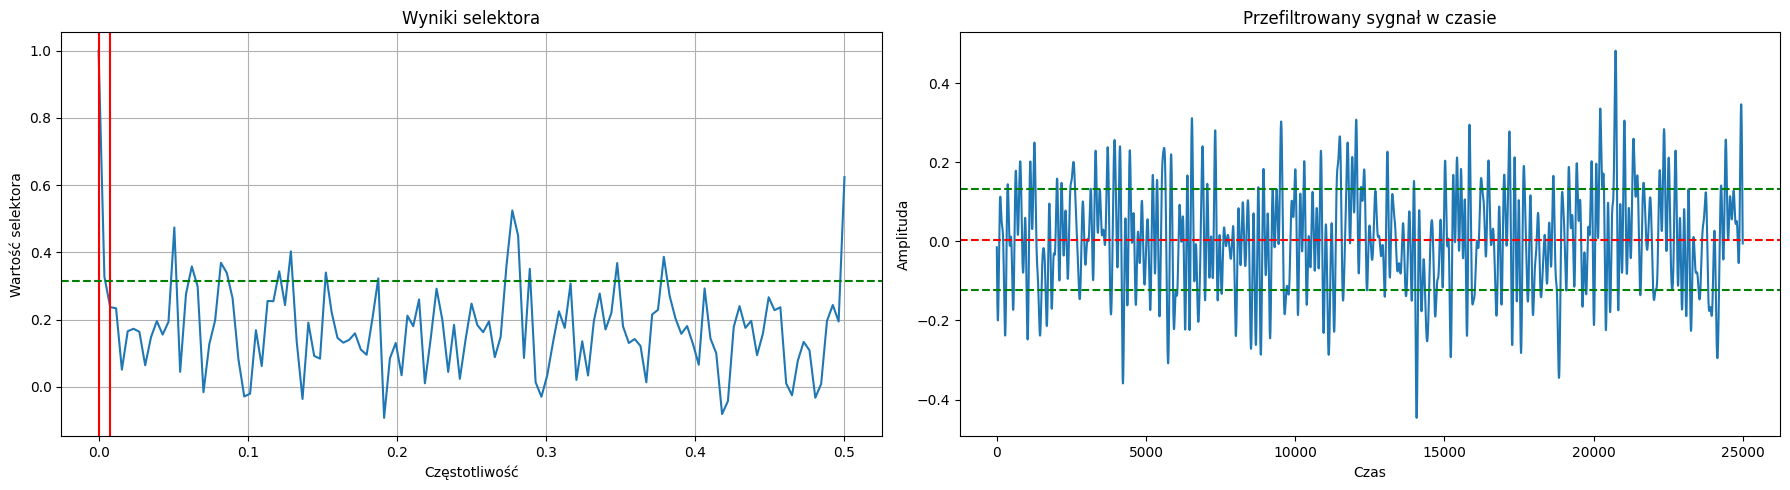

404.39297218346917


array([-0.01504582, -0.02442173, -0.0336594 , ...,  0.01378341,
        0.00406978, -0.00554435], shape=(25000,))

In [1552]:
jb_results = selector.JB(Zxx)
selector_analysis(sk_results,threshold_factor)

mean:0.95631406498758
std:0.01841177291144442


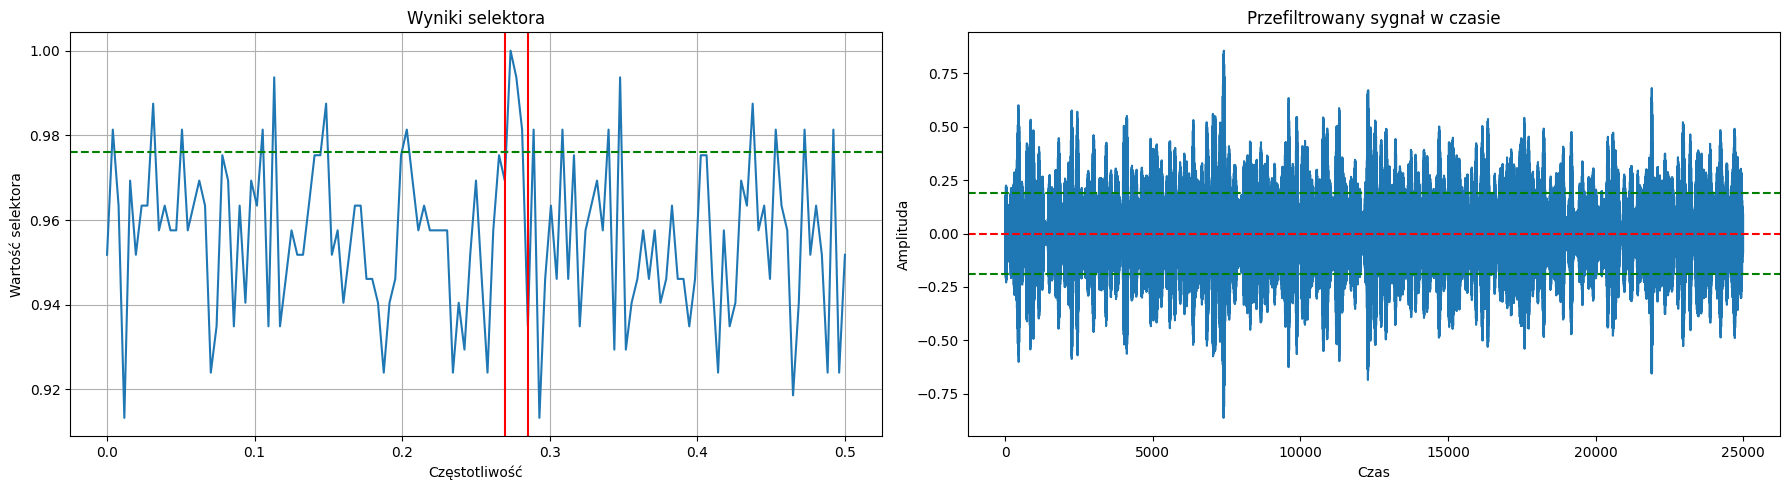

898.9032616159709


array([ 0.08433505,  0.06494213, -0.12035219, ...,  0.0939274 ,
       -0.04110646, -0.08914569], shape=(25000,))

In [1553]:
kss_results = selector.KSS(Zxx)
selector_analysis(kss_results,threshold_factor)

mean:0.3690312300222413
std:0.16497002715290338


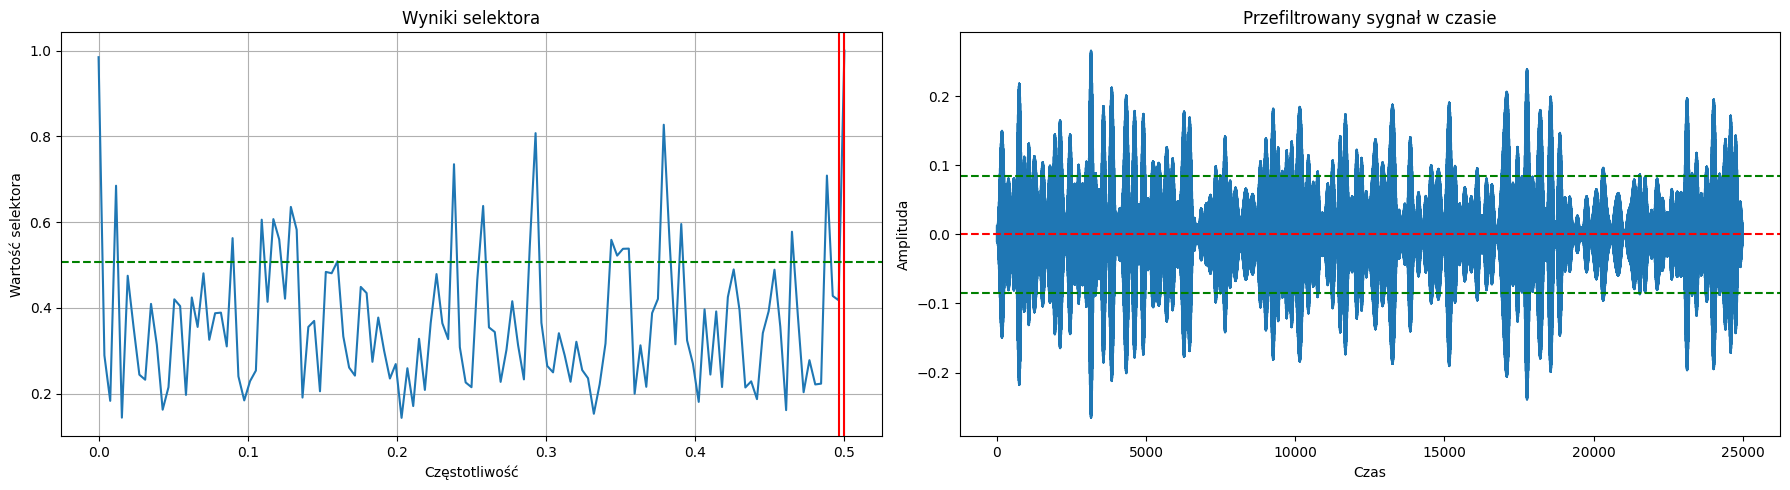

179.2904085562318


array([ 0.01146785, -0.01124311,  0.01103802, ..., -0.01225633,
        0.01197483, -0.01171188], shape=(25000,))

In [1554]:
ad_results = selector.AD(Zxx)
selector_analysis(ad_results,threshold_factor)

mean:0.012822053174393153
std:0.005926809664210424


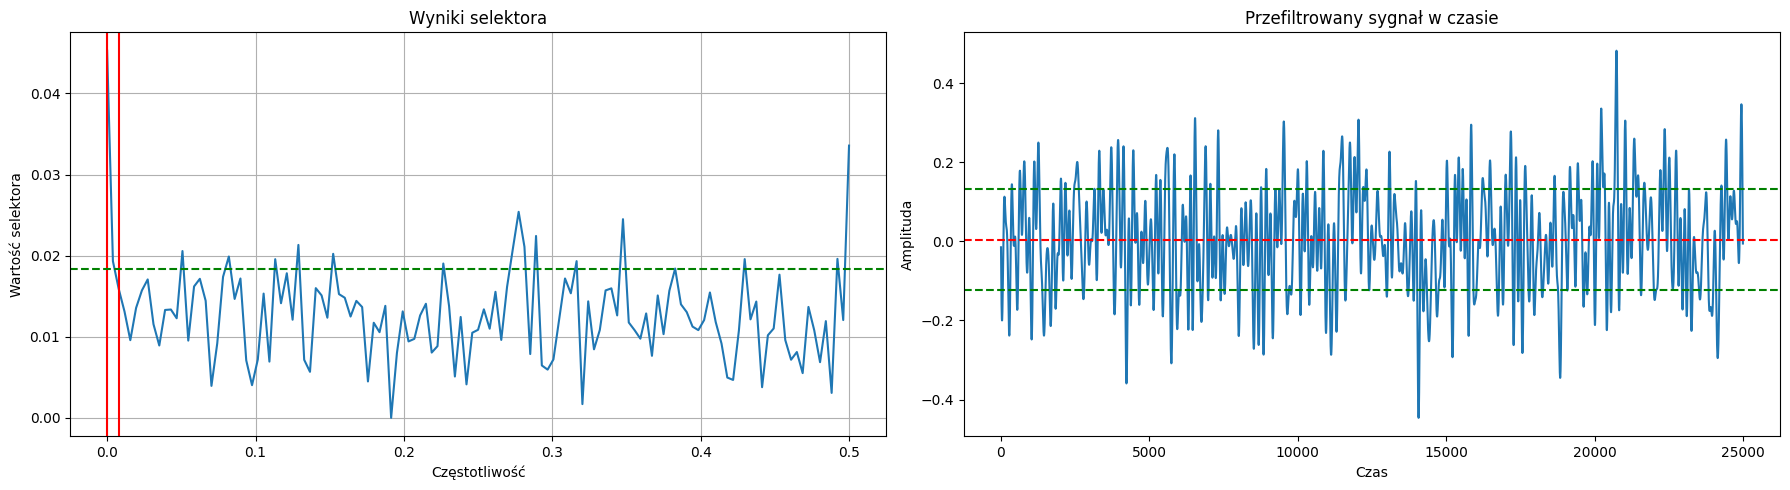

404.39297218346917


array([-0.01504582, -0.02442173, -0.0336594 , ...,  0.01378341,
        0.00406978, -0.00554435], shape=(25000,))

In [1555]:
cvm_results = 1-selector.CVM(Zxx)
selector_analysis(cvm_results,threshold_factor)

mean:-0.016820662810499425
std:0.27746303316603876


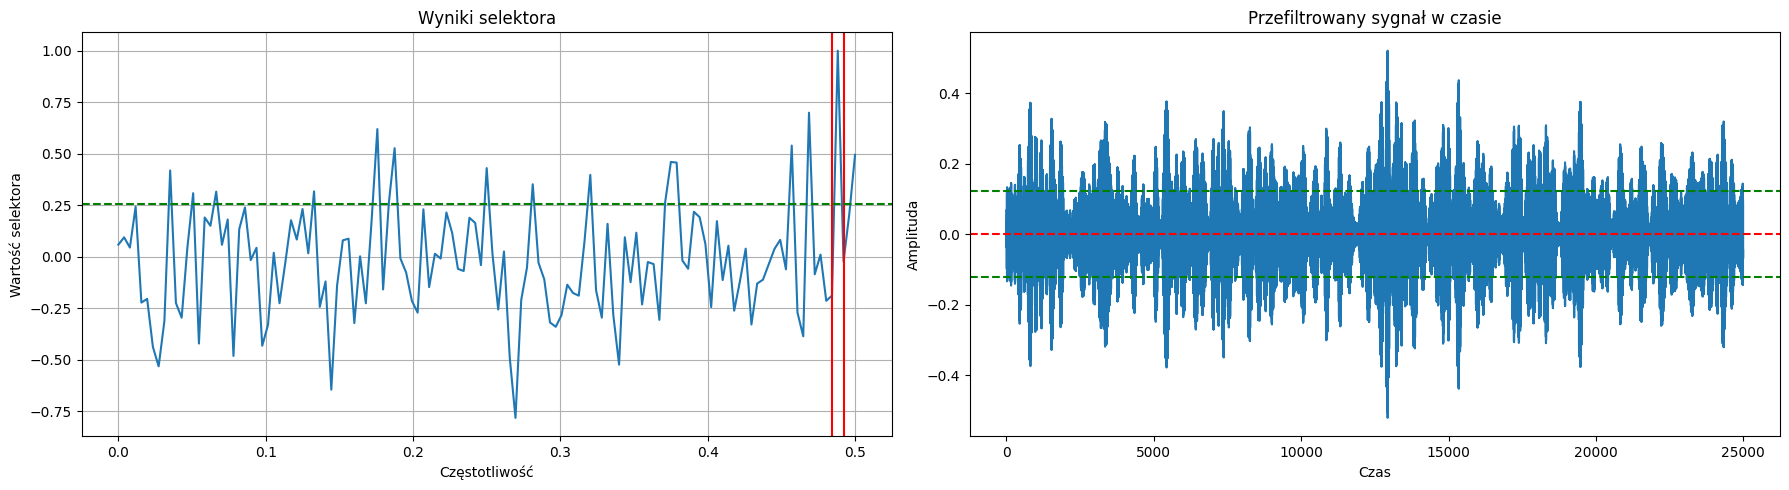

372.0998658175666


array([ 0.03420085, -0.02222734,  0.01012305, ..., -0.06842316,
        0.05738799, -0.04595124], shape=(25000,))

In [1556]:
cvs_results = selector.CVS(Zxx)
selector_analysis(cvs_results,threshold_factor)

## Faktyczne obliczenie wszystkich selektorów


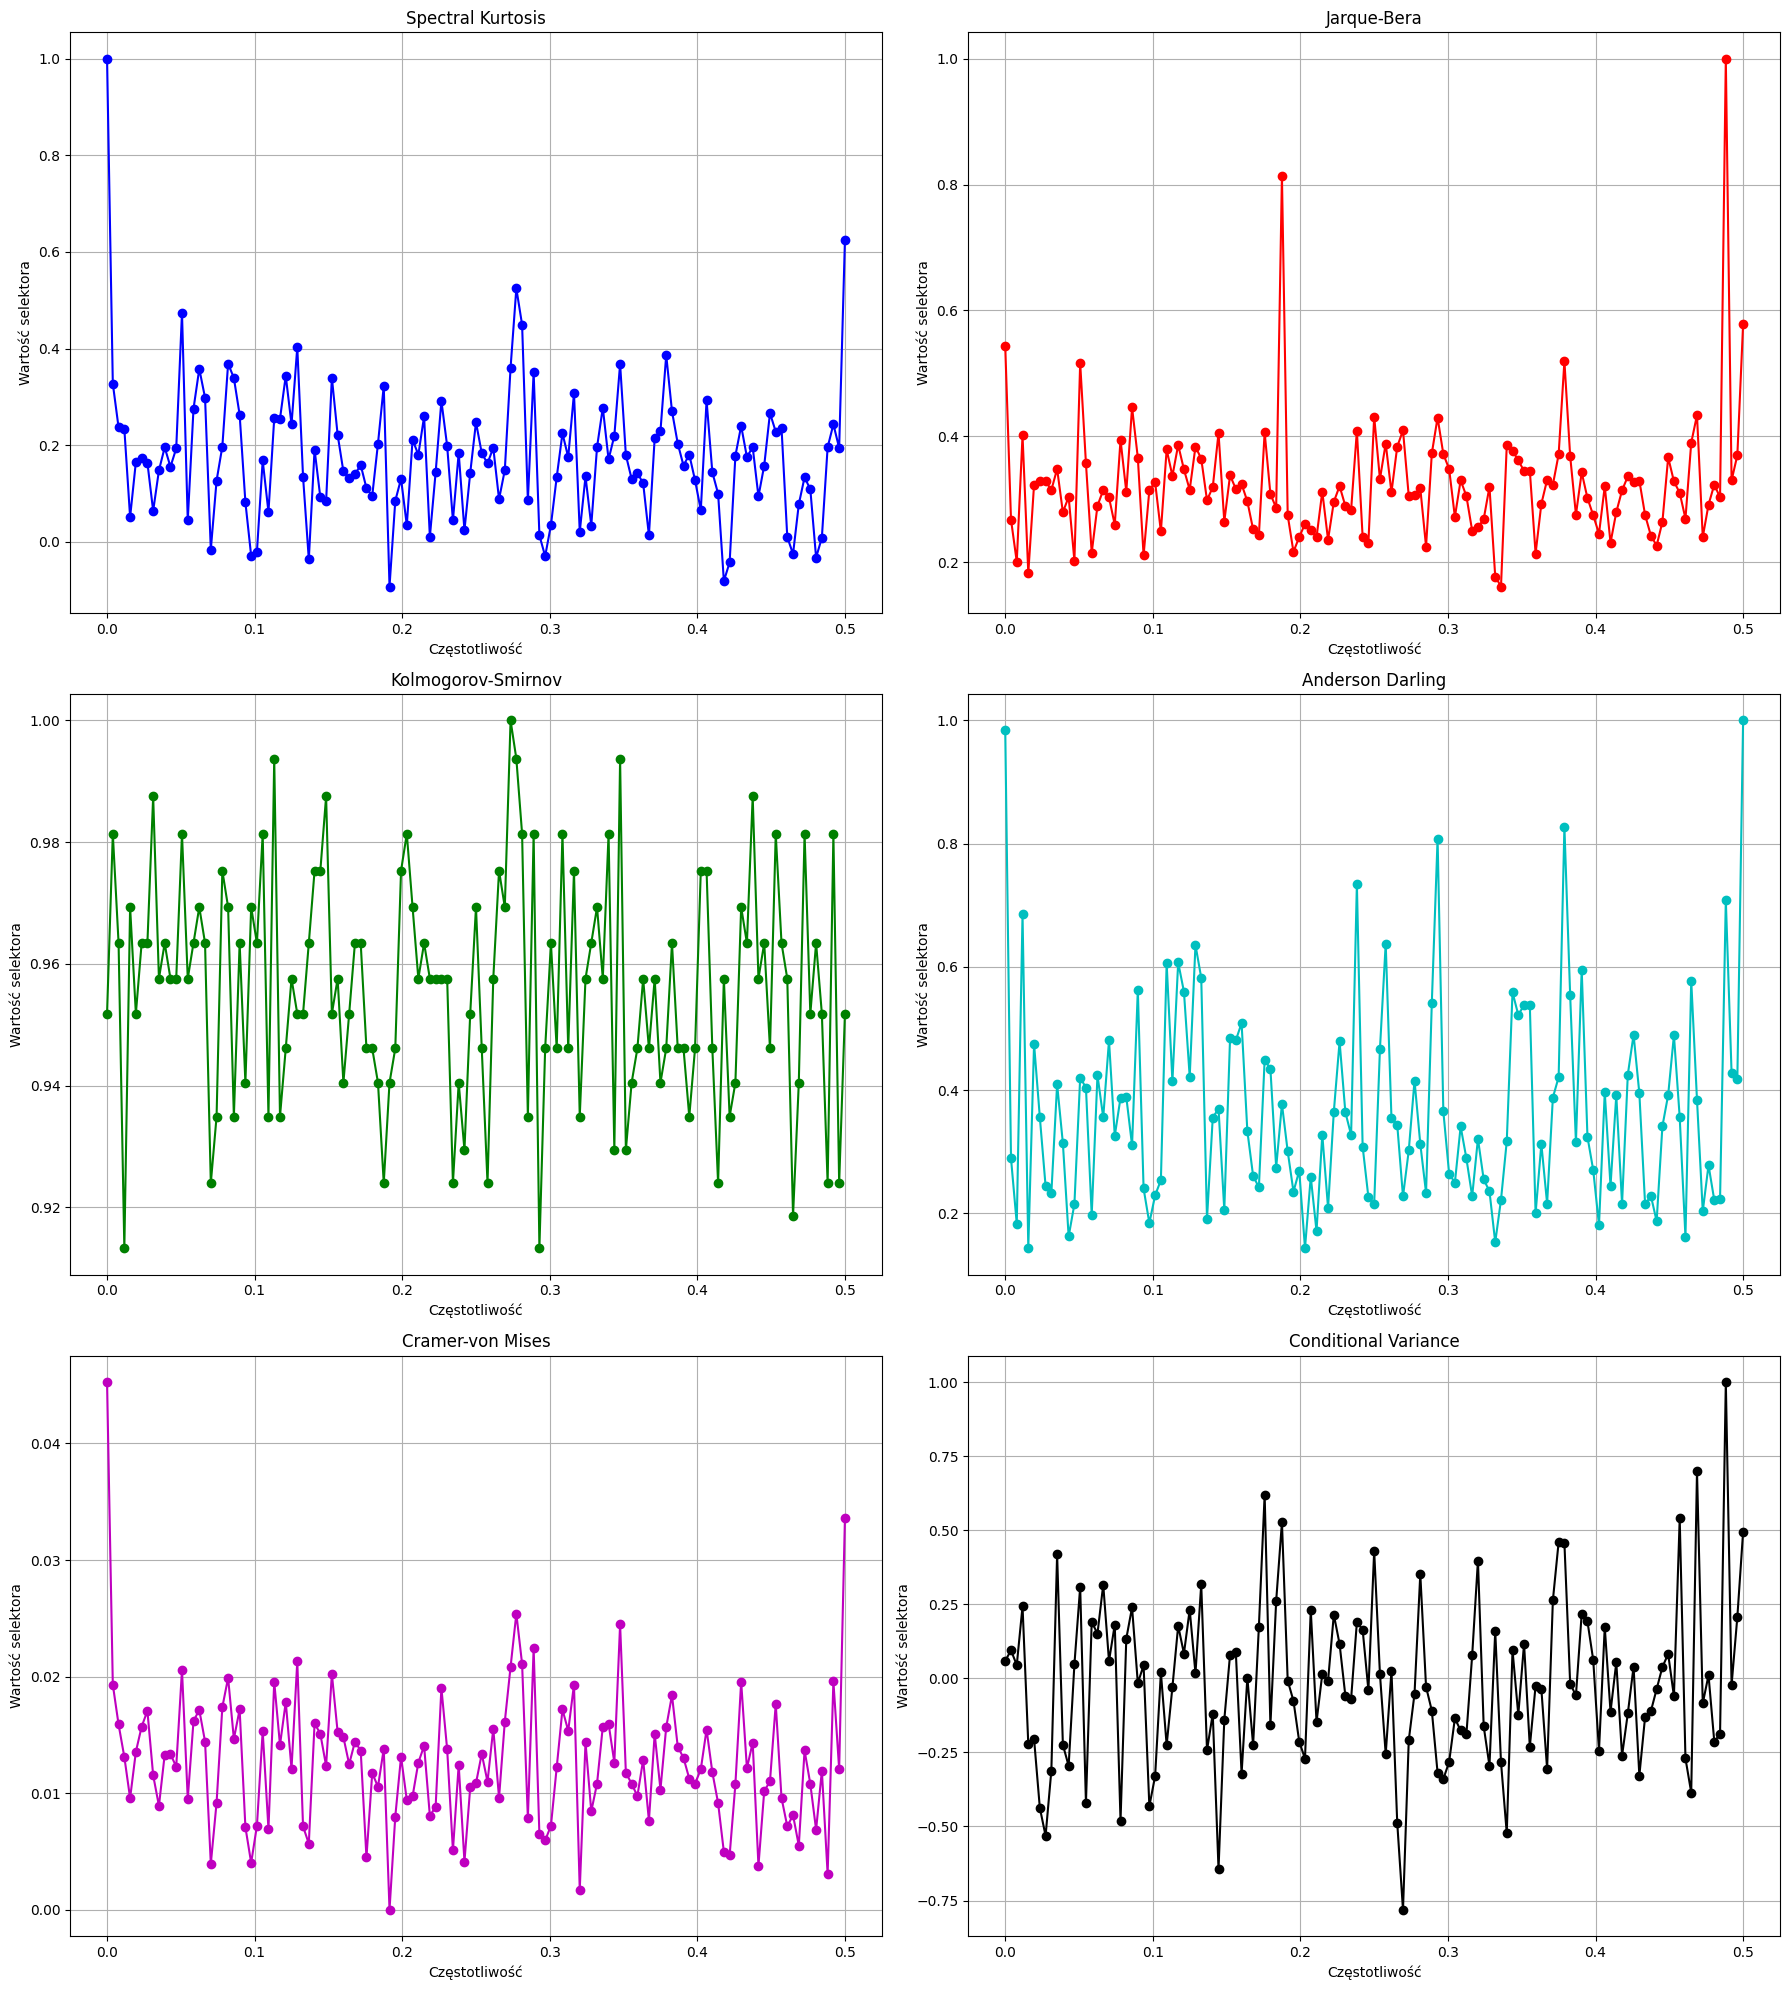

In [1557]:
import ifb_selectors as selector

sk_results = selector.SK(Zxx)
jb_results = selector.JB(Zxx)
kss_results = selector.KSS(Zxx)
ad_results = selector.AD(Zxx)
cvm_results = 1-selector.CVM(Zxx)
cvs_results = selector.CVS(Zxx)

fig, axes = plt.subplots(3,2,figsize=(18,20))
axes[0,0].plot(array_freq,sk_results,'bo-')
axes[0,0].set_title("Spectral Kurtosis")
axes[0,0].set_xlabel("Częstotliwość")
axes[0,0].set_ylabel("Wartość selektora")

axes[0,1].plot(array_freq,jb_results,'ro-')
axes[0,1].set_title("Jarque-Bera")
axes[0,1].set_xlabel("Częstotliwość")
axes[0,1].set_ylabel("Wartość selektora")

axes[1,0].plot(array_freq, kss_results,'go-')
axes[1,0].set_title("Kolmogorov-Smirnov")
axes[1,0].set_xlabel("Częstotliwość")
axes[1,0].set_ylabel("Wartość selektora")

axes[1,1].plot(array_freq, ad_results,'co-')
axes[1,1].set_title("Anderson Darling")
axes[1,1].set_xlabel("Częstotliwość")
axes[1,1].set_ylabel("Wartość selektora")

axes[2,0].plot(array_freq, cvm_results,'mo-')
axes[2,0].set_title("Cramer-von Mises")
axes[2,0].set_xlabel("Częstotliwość")
axes[2,0].set_ylabel("Wartość selektora")

axes[2,1].plot(array_freq, cvs_results,'ko-')
axes[2,1].set_title("Conditional Variance")
axes[2,1].set_xlabel("Częstotliwość")
axes[2,1].set_ylabel("Wartość selektora")

axes[0,0].grid()
axes[0,1].grid()
axes[1,0].grid()
axes[1,1].grid()
axes[2,0].grid()
axes[2,1].grid()

plt.tight_layout()
plt.show()